# Best Model Feature Importance

This notebook interprets the locked **SRM Global Linear Composite**. It does not retune or replace the selected model. OOF cross-validation is used only for performance estimation; the full-data fit is used only for coefficient and contribution interpretation.

No CSV, JSON, figure, or report files are exported by this notebook.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Could not find repo root")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import DEFAULT_CONFIG, set_global_seeds
from src.data.audit import add_visit_time
from src.data.trackfa_pairs import infer_trackfa_feature_groups, trackfa_pairs_to_long
from src.eval.feature_importance import (
    annual_feature_contributions,
    bootstrap_srm_coefficients,
    coefficient_importance_table,
    correlation_redundancy,
    domain_contributions,
    fit_locked_srm_full_data,
    infer_feature_domains,
    integrated_feature_importance,
    lofo_srm_importance,
    selected_srm_config_from_log,
    selection_stability_summary,
)
from src.eval.intervals import adjacent_pair_interval_effect_summary, annual_tuning_diagnostics, interval_effect_summary
from src.models.srm_global import srm_global_loocv

set_global_seeds(DEFAULT_CONFIG.random_state)
RANDOM_SEED = DEFAULT_CONFIG.random_state
CV_N_SPLITS = DEFAULT_CONFIG.cv_n_splits
N_BOOT_PERFORMANCE = 300
N_BOOT_COEFFICIENTS = 1000
N_BOOT_LOFO = 100
CORRELATION_THRESHOLD = 0.70

pairs_path = REPO_ROOT / "data" / "processed" / "trackfa_pairs_drop3poms.csv"
long_path = REPO_ROOT / "data" / "processed" / "trackfa_long.csv"
log_path = REPO_ROOT / "results" / "srm_composite_optimization_log.csv"

if not pairs_path.exists():
    raise FileNotFoundError(f"Required modelling dataset not found: {pairs_path}")
if not log_path.exists():
    raise FileNotFoundError(f"Required SRM optimization log not found: {log_path}")

pairs_df = pd.read_csv(pairs_path)
pair_long_df = trackfa_pairs_to_long(pairs_df)
long_df = add_visit_time(pd.read_csv(long_path), visit_col="visit") if long_path.exists() else None
feature_groups = infer_trackfa_feature_groups(pairs_df)
imaging_cols = [c for c in feature_groups.all_neuroimaging if c in pair_long_df.columns]
config = selected_srm_config_from_log(pd.read_csv(log_path))

print(f"Loaded annual paired modelling table: {pairs_path.name}")
print(f"Annual long rows: {pair_long_df.shape[0]}, pair intervals: {pair_long_df['pair_id'].nunique()}, participants: {pair_long_df['subject'].nunique()}")
print(f"MRI feature candidates available: {len(imaging_cols)}")
print(f"Coefficient bootstrap resamples requested: {N_BOOT_COEFFICIENTS}")

Loaded annual paired modelling table: trackfa_pairs_drop3poms.csv
Annual long rows: 414, pair intervals: 207, participants: 117
MRI feature candidates available: 146
Coefficient bootstrap resamples requested: 1000


## 1. Best Model Summary

The table below locks the model configuration before interpretation. These settings come from the existing SRM optimization log and are not retuned here.

In [2]:
locked_fit = fit_locked_srm_full_data(
    pair_long_df,
    imaging_cols,
    pair_col="pair_id",
    visit_col="visit",
    split_group_col="subject",
    selection_method=config["selection_method"],
    k=config["k"],
    ridge=config["ridge"],
    covariance_shrinkage=config["covariance_shrinkage"],
    z_clip=config["z_clip"],
)
selected_features = locked_fit["feature_names"]

summary_rows = [
    {"item": "Best model", "value": "SRM Global Linear Composite"},
    {"item": "Selected hyperparameters", "value": {k: config[k] for k in ["ridge", "covariance_shrinkage", "z_clip", "k"]}},
    {"item": "Regularisation", "value": config["regularisation"]},
    {"item": "Feature-selection method", "value": config["selection_method"]},
    {"item": "Number of selected features", "value": len(selected_features)},
    {"item": "Preprocessing", "value": "complete-case MRI rows; train/full-fit standardisation; optional z clipping from locked config"},
    {"item": "Tuning metric", "value": config["tuning_metric"]},
    {"item": "Interpretation fit", "value": "locked full-data SRM fit; not used as performance estimate"},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
print("Selected features")
display(pd.DataFrame({"feature": selected_features}))

,item,value
0,Best model,SRM Global Linear Composite
1,Selected hyperparameters,"{'ridge': 0.0, 'covariance_shrinkage': 0.4, 'z..."
2,Regularisation,"{'ridge': 0.0, 'covariance_shrinkage': 0.4, 'z..."
3,Feature-selection method,none
4,Number of selected features,146
5,Preprocessing,complete-case MRI rows; train/full-fit standar...
6,Tuning metric,mean_validation_annual_dz
7,Interpretation fit,locked full-data SRM fit; not used as performa...


Selected features


,feature
0,AD_ACR
1,AD_ALIC
2,AD_CP
3,AD_CST
4,AD_Cing
...,...
141,sFA_c3c5
142,sMD_c3c5
143,sRD_c3c5
144,x3rd_Ventricle


## 2. Current OOF Performance

These values are generated from subject-level grouped OOF predictions using the locked configuration. The annual paired table is used for V1->V2 and V2->V3; V1->V3 is reported separately as cumulative 24-month sensitivity when the long visit table is available.

In [3]:
annual_oof = srm_global_loocv(
    pair_long_df,
    imaging_cols,
    subject_col="pair_id",
    visit_col="visit",
    selection_method=config["selection_method"],
    k=config["k"],
    ridge=config["ridge"],
    covariance_shrinkage=config["covariance_shrinkage"],
    z_clip=config["z_clip"],
    cv_n_splits=CV_N_SPLITS,
    random_seed=RANDOM_SEED,
    compute_ci=False,
    split_group_col="subject",
    start_visit=1,
    end_visit=2,
)
annual_intervals = adjacent_pair_interval_effect_summary(
    annual_oof["oof_df"],
    pair_col="pair_id",
    visit_col="visit",
    score_col="score",
    n_boot=N_BOOT_PERFORMANCE,
    seed=RANDOM_SEED,
)
annual_diag = annual_tuning_diagnostics(annual_intervals)

if long_df is not None:
    long_features = [f for f in selected_features if f in long_df.columns]
    cumulative_oof = srm_global_loocv(
        long_df,
        long_features,
        subject_col="subject_id",
        visit_col="visit",
        selection_method="none",
        k=len(long_features),
        ridge=config["ridge"],
        covariance_shrinkage=config["covariance_shrinkage"],
        z_clip=config["z_clip"],
        cv_n_splits=CV_N_SPLITS,
        random_seed=RANDOM_SEED,
        compute_ci=False,
        start_visit=1,
        end_visit=3,
    )
    cumulative_intervals = interval_effect_summary(
        cumulative_oof["oof_df"],
        subject_col="subject_id",
        visit_col="visit",
        score_col="score",
        time_col=None,
        intervals=[(1, 3, "V1->V3", False)],
        n_boot=N_BOOT_PERFORMANCE,
        seed=RANDOM_SEED,
    )
else:
    cumulative_intervals = pd.DataFrame()

performance_rows = [
    {"metric": "V1->V2 d_z", "value": annual_diag["dz_v1_v2"]},
    {"metric": "V2->V3 d_z", "value": annual_diag["dz_v2_v3"]},
    {"metric": "mean annual d_z", "value": annual_diag["mean_validation_annual_dz"]},
    {"metric": "|d12-d23|", "value": annual_diag["annual_interval_gap"]},
    {"metric": "P(delta>0) mean across annual intervals", "value": annual_diag["p_progression"]},
]
for _, row in annual_intervals.iterrows():
    performance_rows.append({"metric": f"{row['interval']} P(delta>0)", "value": row["p_delta_positive"]})
if not cumulative_intervals.empty:
    performance_rows.append({"metric": "V1->V3 cumulative d_z", "value": cumulative_intervals.iloc[0]["d_z"]})

print("Annual interval OOF details")
display(annual_intervals)
if not cumulative_intervals.empty:
    print("24-month cumulative OOF details")
    display(cumulative_intervals)
print("Locked-model performance summary")
display(pd.DataFrame(performance_rows))

Annual interval OOF details


,interval,n_pairs,mean_change,sd_change,d_z,d_z_ci_low,d_z_ci_high,p_delta_positive
0,V1->V2,108,2.079592,1.854609,1.12131,0.914700,1.404506,0.870370
1,V2->V3,99,1.799548,2.311588,0.77849,0.579591,0.994504,0.767677


24-month cumulative OOF details


,interval,start_visit,end_visit,annualised,n_pairs,mean_change,sd_change,d_z,d_z_ci_low,d_z_ci_high,p_delta_positive
0,V1->V3,1,3,False,101,6.220436,4.792254,1.298019,1.020413,1.609556,0.930693


Locked-model performance summary


,metric,value
0,V1->V2 d_z,1.121310
1,V2->V3 d_z,0.778490
2,mean annual d_z,0.949900
3,|d12-d23|,0.342820
4,P(delta>0) mean across annual intervals,0.819024
5,V1->V2 P(delta>0),0.870370
6,V2->V3 P(delta>0),0.767677
7,V1->V3 cumulative d_z,1.298019


## 3. Standardised Coefficients

The SRM score is linear: `Z = w^T X`. Coefficients below are comparable because MRI predictors are standardised before fitting. Coefficient magnitude is a conditional model weight; it is not, by itself, biological importance.

,feature,standardised_coefficient,absolute_coefficient,coefficient_sign,rank_by_absolute_coefficient
0,x4th_Ventricle,3.282747,3.282747,1,1
1,Hippocampus,2.743133,2.743133,1,2
2,TotalBrainWMVol_nocereb,1.840984,1.840984,1,3
3,Caudate,-1.591254,1.591254,-1,4
4,Midbrain,-1.564900,1.564900,-1,5
...,...,...,...,...,...
141,AD_EC,0.004391,0.004391,1,142
142,AD_PCT,0.003250,0.003250,1,143
143,bt2CSA_C12_UMN,-0.002694,0.002694,-1,144
144,RD_MCP,0.001187,0.001187,1,145


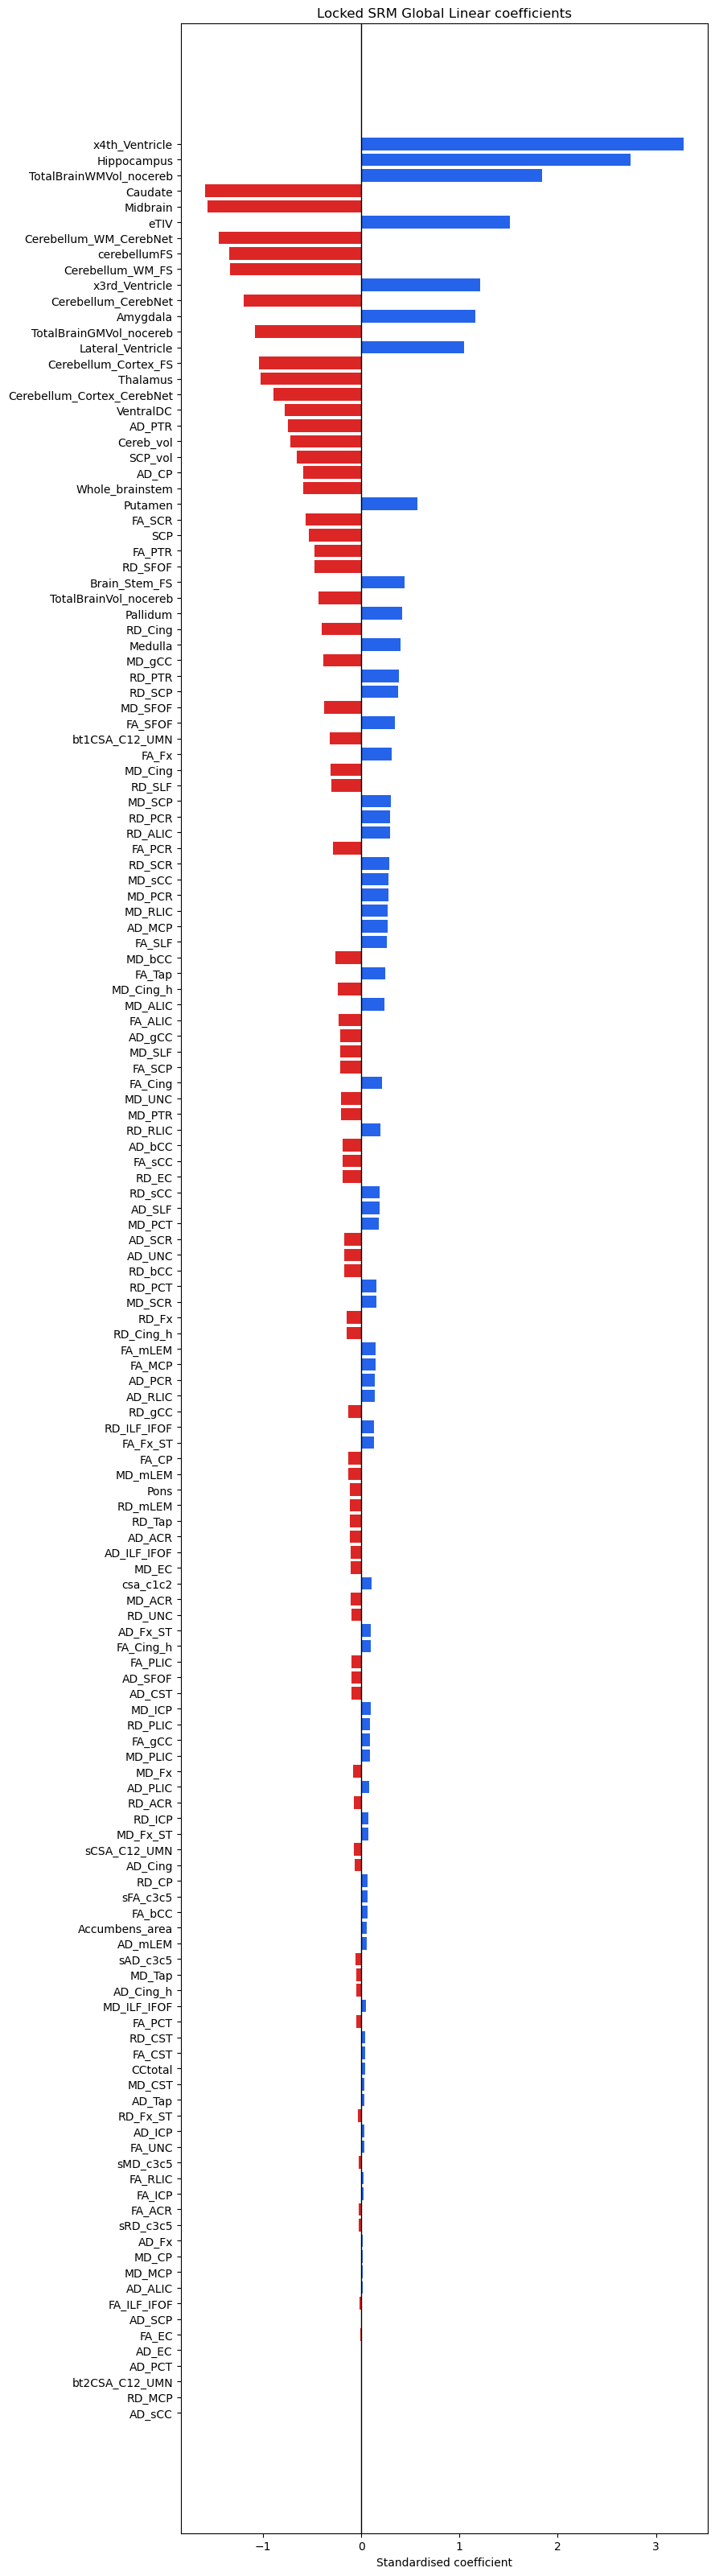

In [4]:
coef_table = coefficient_importance_table(selected_features, locked_fit["coef"])
display(coef_table)

plot_df = coef_table.sort_values("absolute_coefficient", ascending=True)
fig, ax = plt.subplots(figsize=(9, max(6, 0.22 * len(plot_df))))
colors = np.where(plot_df["standardised_coefficient"] >= 0, "#2563eb", "#dc2626")
ax.barh(plot_df["feature"], plot_df["standardised_coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Standardised coefficient")
ax.set_title("Locked SRM Global Linear coefficients")
plt.tight_layout()
display(fig)
plt.close(fig)

## 4. Bootstrap Stability

Bootstrap refits resample participants, not rows. Hyperparameters are fixed to the locked model configuration. The full-data interpretation coefficient is shown alongside the bootstrap distribution.

Bootstrap refits retained: 1000 / 1000


,feature,full_data_coefficient,bootstrap_median_coefficient,bootstrap_ci_low,bootstrap_ci_high,selection_frequency,positive_sign_frequency,negative_sign_frequency,sign_consistency,crosses_zero
0,x4th_Ventricle,3.282747,3.413542,1.926606,5.407063,1.0,1.000,0.000,1.000,False
1,Hippocampus,2.743133,2.823794,1.306306,4.559546,1.0,1.000,0.000,1.000,False
2,TotalBrainWMVol_nocereb,1.840984,1.965086,0.649767,3.659852,1.0,0.998,0.002,0.998,True
3,Caudate,-1.591254,-1.683442,-3.696271,-0.048893,1.0,0.022,0.978,0.978,True
4,Midbrain,-1.564900,-1.690137,-2.848139,-0.731152,1.0,0.000,1.000,1.000,False
...,...,...,...,...,...,...,...,...,...,...
141,AD_EC,0.004391,0.008396,-0.307730,0.374904,1.0,0.525,0.475,0.525,True
142,AD_PCT,0.003250,-0.011727,-0.378560,0.305557,1.0,0.469,0.531,0.531,True
143,bt2CSA_C12_UMN,-0.002694,0.000795,-0.457258,0.418594,1.0,0.501,0.499,0.501,True
144,RD_MCP,0.001187,0.001429,-0.209496,0.190269,1.0,0.507,0.493,0.507,True


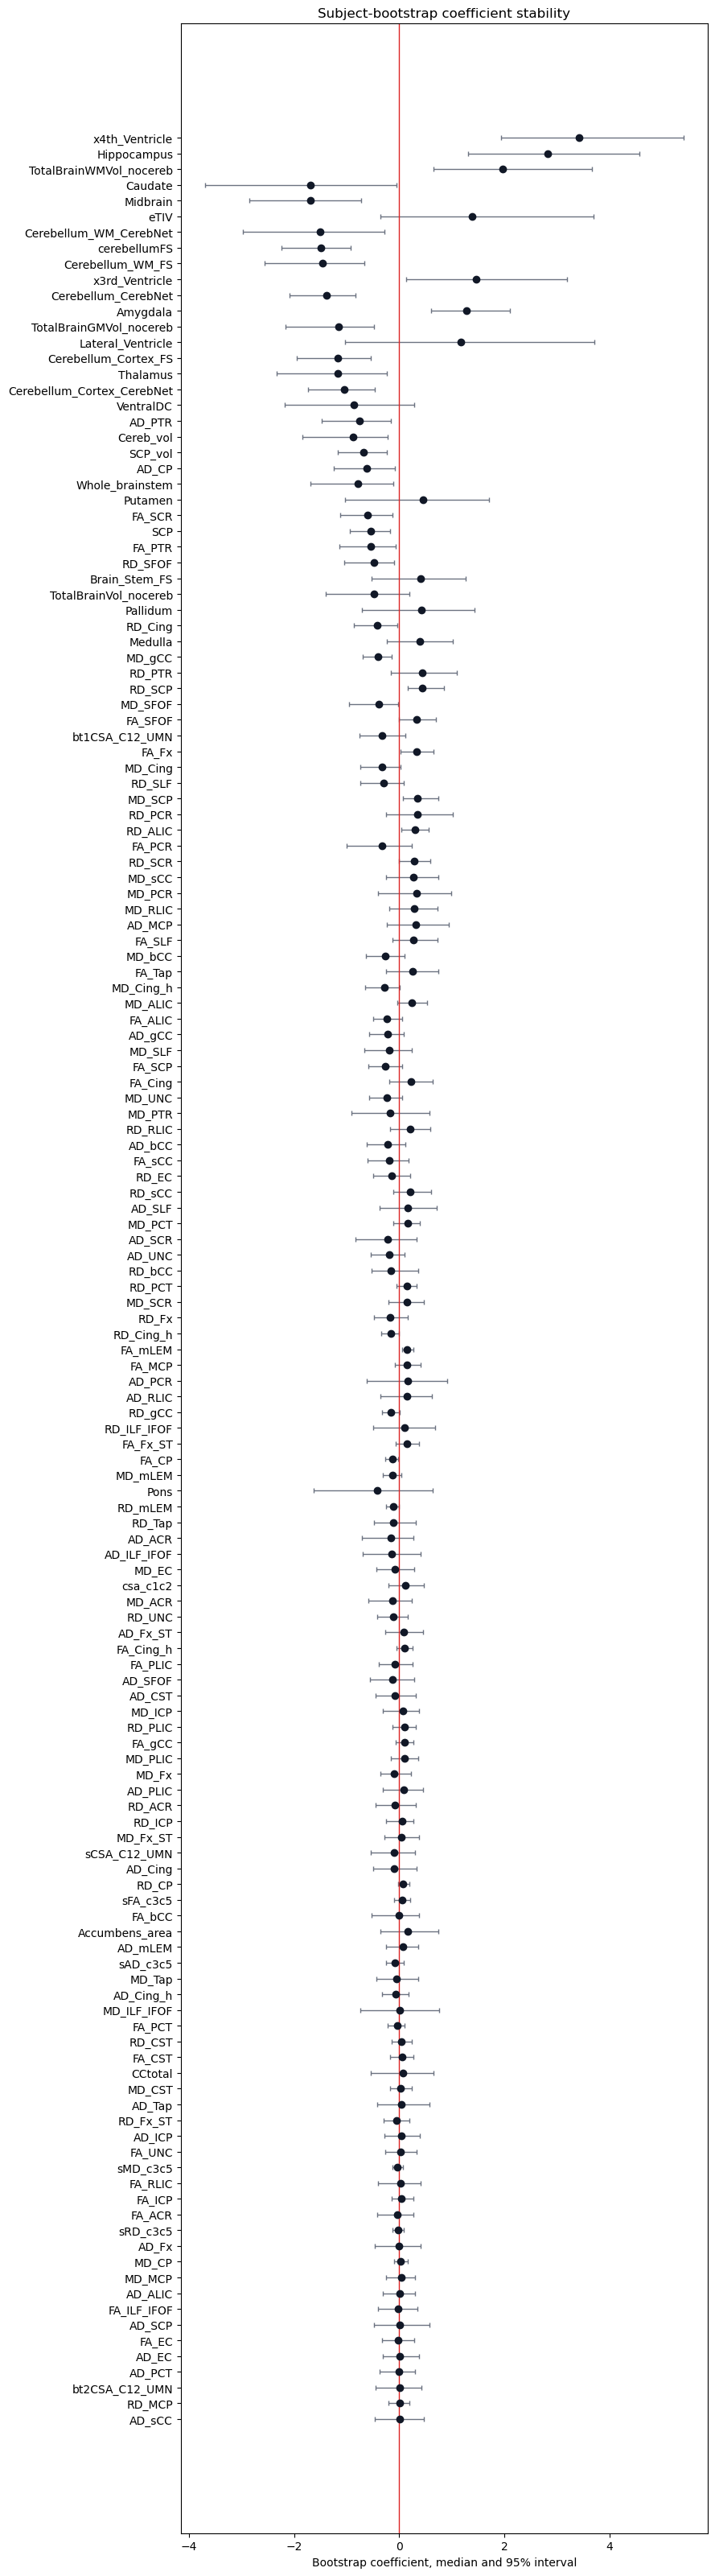

In [5]:
boot = bootstrap_srm_coefficients(
    pair_long_df,
    imaging_cols,
    pair_col="pair_id",
    visit_col="visit",
    split_group_col="subject",
    selection_method=config["selection_method"],
    k=config["k"],
    ridge=config["ridge"],
    covariance_shrinkage=config["covariance_shrinkage"],
    z_clip=config["z_clip"],
    n_boot=N_BOOT_COEFFICIENTS,
    random_seed=RANDOM_SEED,
    locked_feature_names=selected_features,
    full_coef=locked_fit["coef"],
)
bootstrap_table = boot["summary"].sort_values("full_data_coefficient", key=lambda s: s.abs(), ascending=False, kind="mergesort").reset_index(drop=True)
print(f"Bootstrap refits retained: {boot['n_boot_kept']} / {N_BOOT_COEFFICIENTS}")
display(bootstrap_table)

forest_df = bootstrap_table.sort_values("full_data_coefficient", key=lambda s: s.abs(), ascending=True)
fig, ax = plt.subplots(figsize=(9, max(6, 0.22 * len(forest_df))))
y = np.arange(len(forest_df))
ax.errorbar(
    forest_df["bootstrap_median_coefficient"],
    y,
    xerr=[
        forest_df["bootstrap_median_coefficient"] - forest_df["bootstrap_ci_low"],
        forest_df["bootstrap_ci_high"] - forest_df["bootstrap_median_coefficient"],
    ],
    fmt="o",
    color="#111827",
    ecolor="#6b7280",
    elinewidth=1,
    capsize=2,
)
ax.axvline(0, color="#dc2626", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(forest_df["feature"])
ax.set_xlabel("Bootstrap coefficient, median and 95% interval")
ax.set_title("Subject-bootstrap coefficient stability")
plt.tight_layout()
display(fig)
plt.close(fig)

## 5. Annual Feature Contributions

For a linear score, the observed longitudinal change decomposes exactly as `delta Z = sum_j w_j delta X_j`. This section measures which features actually drive the observed annual composite change.

,feature,mean_standardized_feature_change_V1->V2,mean_contribution_V1->V2,mean_standardized_feature_change_V2->V3,mean_contribution_V2->V3,contribution_gap,absolute_annual_contribution
0,x4th_Ventricle,0.047763,0.156795,0.054745,0.179714,-0.022919,0.168255
1,cerebellumFS,-0.138539,0.186553,-0.086822,0.116913,0.069640,0.151733
2,Cerebellum_WM_FS,-0.115769,0.154879,-0.092302,0.123484,0.031395,0.139181
3,Cerebellum_CerebNet,-0.139986,0.167784,-0.079747,0.095583,0.072201,0.131684
4,Cerebellum_Cortex_FS,-0.134440,0.139383,-0.078935,0.081837,0.057545,0.110610
...,...,...,...,...,...,...,...
141,MD_MCP,-0.021305,-0.000330,0.005192,0.000080,-0.000410,0.000205
142,FA_EC,-0.000499,0.000003,-0.030854,0.000170,-0.000167,0.000086
143,AD_PCT,-0.040226,-0.000131,-0.002885,-0.000009,-0.000121,0.000070
144,RD_MCP,-0.042302,-0.000050,0.004689,0.000006,-0.000056,0.000028


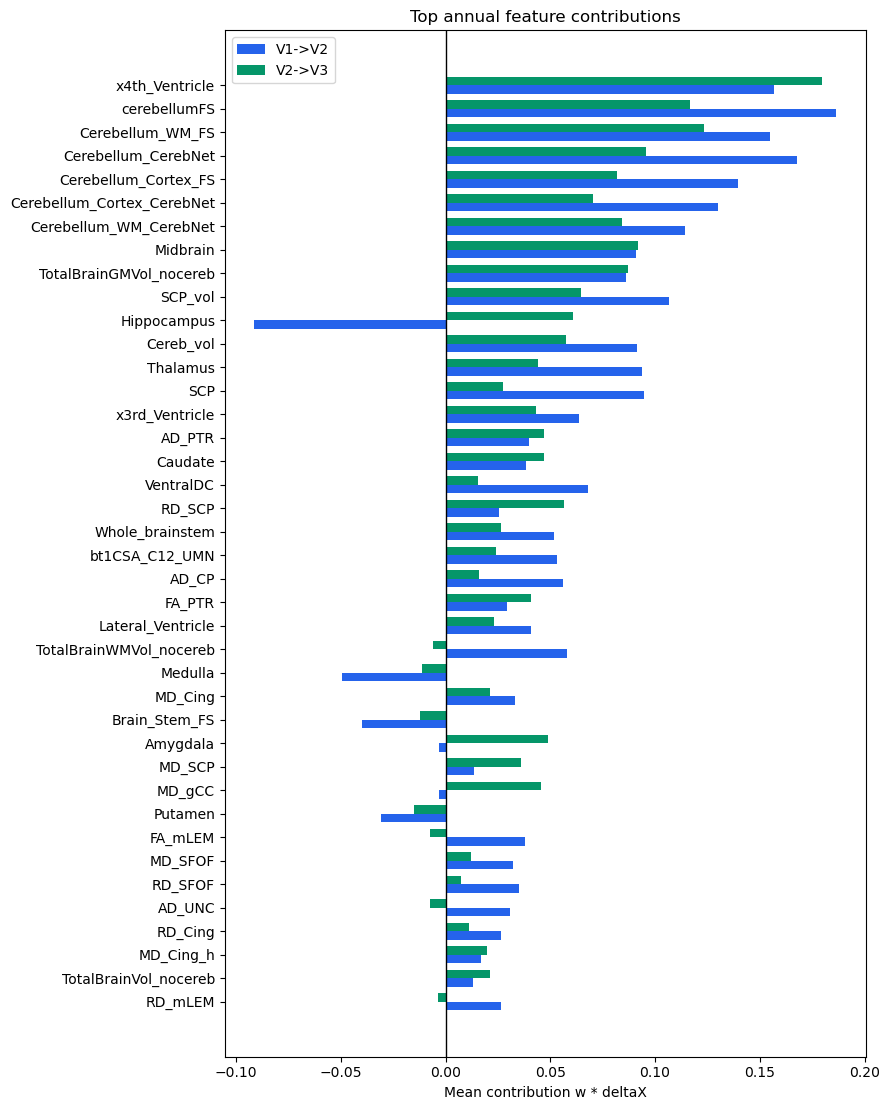

In [6]:
contribution_long, contribution_table = annual_feature_contributions(locked_fit, pair_col="pair_id", visit_col="visit")
display(contribution_table)

plot_df = contribution_table.head(40).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(6, 0.28 * len(plot_df))))
y = np.arange(len(plot_df))
ax.barh(y - 0.18, plot_df["mean_contribution_V1->V2"], height=0.35, label="V1->V2", color="#2563eb")
ax.barh(y + 0.18, plot_df["mean_contribution_V2->V3"], height=0.35, label="V2->V3", color="#059669")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Mean contribution w * deltaX")
ax.set_title("Top annual feature contributions")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 6. V1->V2 vs V2->V3 Contribution Difference

This section investigates why the annual sensitivity differs between intervals using observed feature contributions only.

,feature,mean_contribution_V1->V2,mean_contribution_V2->V3,contribution_gap,absolute_difference
0,Hippocampus,-0.091431,0.060699,-0.152130,0.152130
1,Cerebellum_CerebNet,0.167784,0.095583,0.072201,0.072201
2,cerebellumFS,0.186553,0.116913,0.069640,0.069640
3,SCP,0.094955,0.027489,0.067466,0.067466
4,TotalBrainWMVol_nocereb,0.057764,-0.005783,0.063547,0.063547
...,...,...,...,...,...
141,AD_PCT,-0.000131,-0.000009,-0.000121,0.000121
142,FA_ILF_IFOF,0.000852,0.000766,0.000086,0.000086
143,RD_MCP,-0.000050,0.000006,-0.000056,0.000056
144,MD_PTR,0.003145,0.003199,-0.000054,0.000054


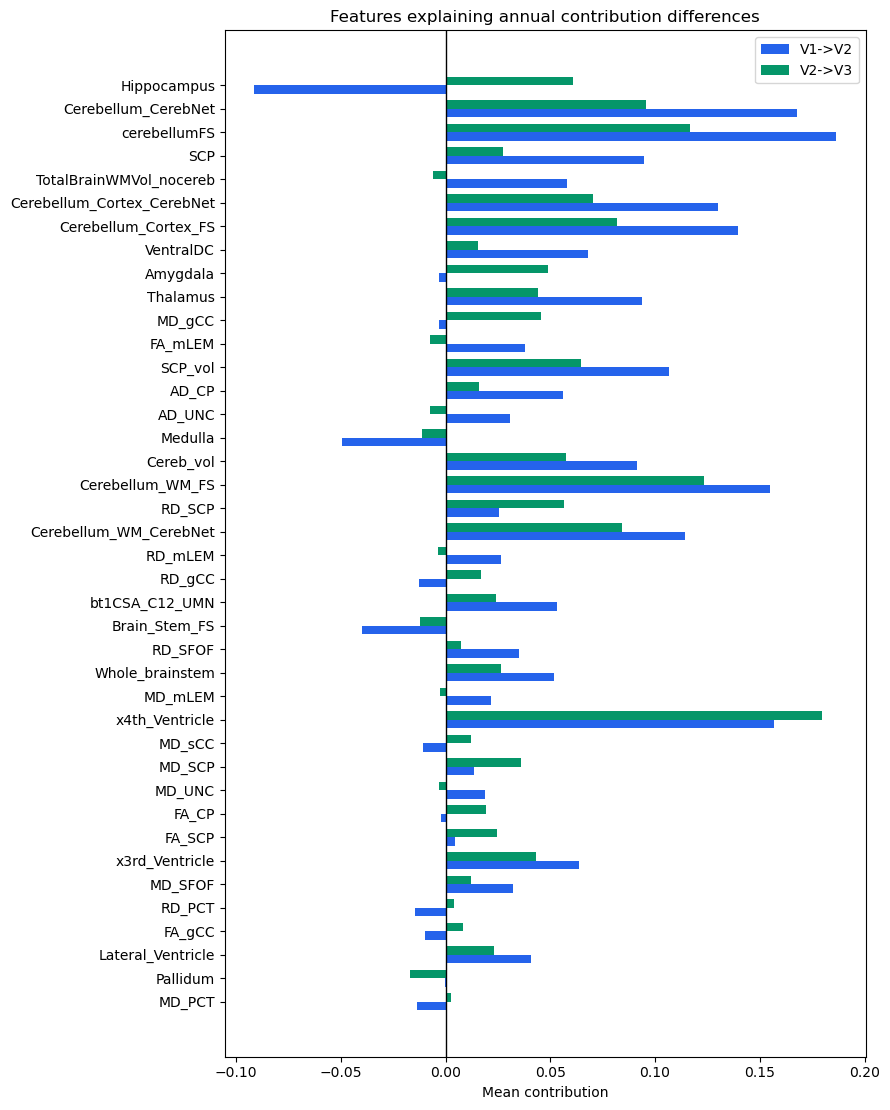

Features contributing most to the V1->V2 signal: cerebellumFS, Cerebellum_CerebNet, x4th_Ventricle, Cerebellum_WM_FS, Cerebellum_Cortex_FS
Features whose contribution weakens most in V2->V3: Cerebellum_CerebNet, cerebellumFS, SCP, TotalBrainWMVol_nocereb, Cerebellum_Cortex_CerebNet
Features with relatively stable contribution across both years: AD_sCC, MD_PTR, RD_MCP, FA_ILF_IFOF, AD_PCT


In [7]:
diff_table = contribution_table[["feature", "mean_contribution_V1->V2", "mean_contribution_V2->V3", "contribution_gap"]].copy()
diff_table["absolute_difference"] = diff_table["contribution_gap"].abs()
diff_table = diff_table.sort_values("absolute_difference", ascending=False, kind="mergesort").reset_index(drop=True)
display(diff_table)

plot_df = diff_table.head(40).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(6, 0.28 * len(plot_df))))
y = np.arange(len(plot_df))
ax.barh(y - 0.18, plot_df["mean_contribution_V1->V2"], height=0.35, label="V1->V2", color="#2563eb")
ax.barh(y + 0.18, plot_df["mean_contribution_V2->V3"], height=0.35, label="V2->V3", color="#059669")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"])
ax.set_xlabel("Mean contribution")
ax.set_title("Features explaining annual contribution differences")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

v12_top = contribution_table.reindex(contribution_table["mean_contribution_V1->V2"].abs().sort_values(ascending=False).index).head(5)["feature"].tolist()
weakens = diff_table.sort_values("contribution_gap", ascending=False).head(5)["feature"].tolist()
stable = diff_table.sort_values("absolute_difference", ascending=True).head(5)["feature"].tolist()
print("Features contributing most to the V1->V2 signal:", ", ".join(v12_top))
print("Features whose contribution weakens most in V2->V3:", ", ".join(weakens))
print("Features with relatively stable contribution across both years:", ", ".join(stable))

## 7. Leave-One-Feature-Out Performance

Each selected feature is removed, the locked SRM specification is refit with fixed hyperparameters, and the same subject-level OOF annual evaluation is repeated. Larger positive loss means the annual progression sensitivity depends more on that feature. Negative loss means removing the feature improved OOF annual performance.

,removed_feature,full_d12,lofo_d12,d12_loss,full_d23,lofo_d23,d23_loss,full_mean_annual_dz,lofo_mean_annual_dz,annual_performance_loss
0,Hippocampus,1.12131,1.077445,0.043865,0.77849,0.725190,0.053300,0.9499,0.901317,0.048583
1,SCP_vol,1.12131,1.078977,0.042333,0.77849,0.758033,0.020457,0.9499,0.918505,0.031395
2,x4th_Ventricle,1.12131,1.123064,-0.001754,0.77849,0.738100,0.040389,0.9499,0.930582,0.019318
3,SCP,1.12131,1.101870,0.019440,0.77849,0.759776,0.018714,0.9499,0.930823,0.019077
4,Midbrain,1.12131,1.101563,0.019747,0.77849,0.769752,0.008738,0.9499,0.935658,0.014242
...,...,...,...,...,...,...,...,...,...,...
141,FA_PCT,1.12131,1.126373,-0.005063,0.77849,0.782716,-0.004227,0.9499,0.954545,-0.004645
142,FA_SCP,1.12131,1.130560,-0.009250,0.77849,0.779233,-0.000743,0.9499,0.954896,-0.004996
143,FA_Cing_h,1.12131,1.132982,-0.011672,0.77849,0.777815,0.000675,0.9499,0.955398,-0.005498
144,AD_SFOF,1.12131,1.130221,-0.008910,0.77849,0.781230,-0.002740,0.9499,0.955725,-0.005825


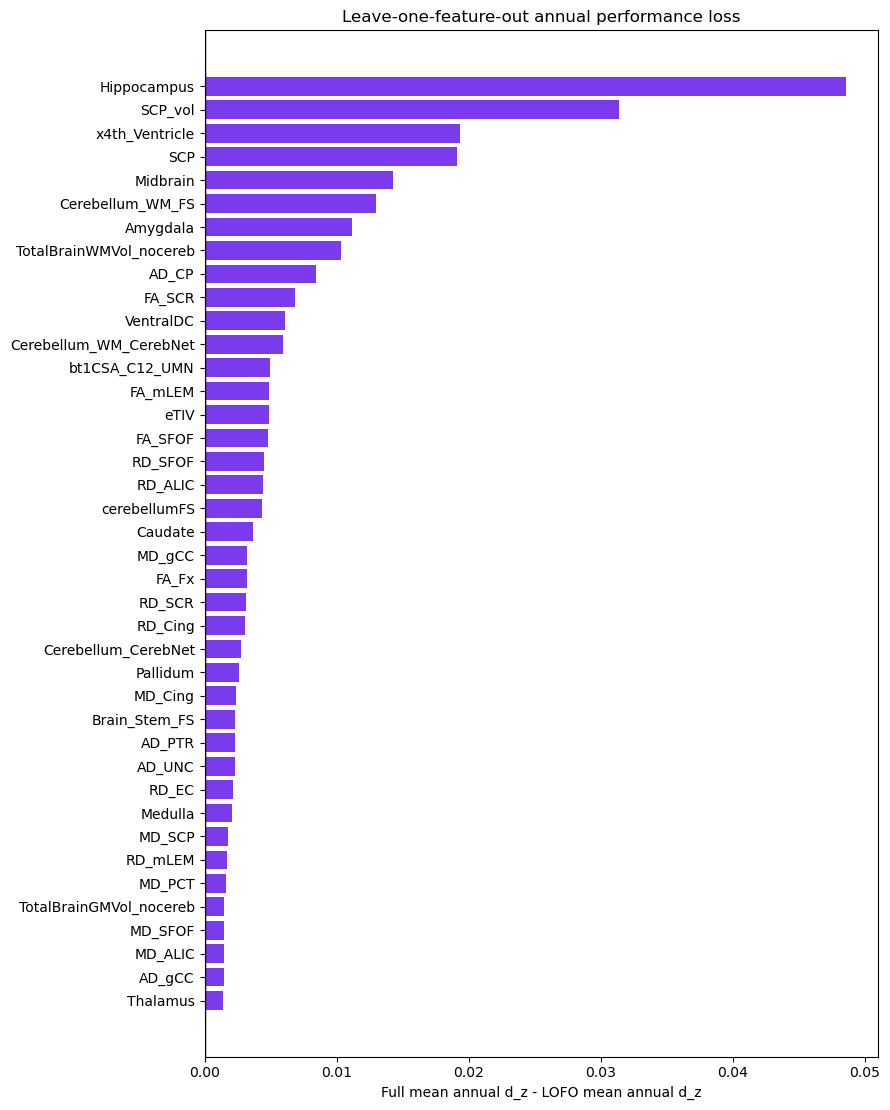

In [8]:
lofo_table = lofo_srm_importance(
    pair_long_df,
    selected_features,
    pair_col="pair_id",
    visit_col="visit",
    split_group_col="subject",
    selection_method=config["selection_method"],
    k=config["k"],
    ridge=config["ridge"],
    covariance_shrinkage=config["covariance_shrinkage"],
    z_clip=config["z_clip"],
    cv_n_splits=CV_N_SPLITS,
    random_seed=RANDOM_SEED,
    n_boot=N_BOOT_LOFO,
)
display(lofo_table)

plot_df = lofo_table.head(40).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(6, 0.28 * len(plot_df))))
colors = np.where(plot_df["annual_performance_loss"] >= 0, "#7c3aed", "#f97316")
ax.barh(plot_df["removed_feature"], plot_df["annual_performance_loss"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Full mean annual d_z - LOFO mean annual d_z")
ax.set_title("Leave-one-feature-out annual performance loss")
plt.tight_layout()
display(fig)
plt.close(fig)

## 8. Selection Stability

Selection frequency measures robustness of selection, not biological importance. For the current locked model, `selection_method='none'`, so all selected imaging features are retained by design; Jaccard is therefore expected to be 1.0 across bootstrap refits.

In [9]:
selection_feature_table, selection_jaccard_table = selection_stability_summary(boot["selected_feature_sets"], selected_features)
display(selection_feature_table)
display(selection_jaccard_table)

,feature,selection_frequency
0,AD_ACR,1.0
1,AD_ALIC,1.0
2,AD_CP,1.0
3,AD_CST,1.0
4,AD_Cing,1.0
...,...,...
141,sFA_c3c5,1.0
142,sMD_c3c5,1.0
143,sRD_c3c5,1.0
144,x3rd_Ventricle,1.0


,n_sets,mean_jaccard,min_jaccard,max_jaccard,median_jaccard,iqr_jaccard
0,1000,1.0,1.0,1.0,1.0,0.0


## 9. Correlation / Redundancy

Correlated MRI predictors may substitute for one another. A small coefficient is not evidence of biological irrelevance when the feature is strongly redundant with another selected predictor.

High-correlation threshold: |r| > 0.7
Correlation matrix


,AD_ACR,AD_ALIC,AD_CP,AD_CST,AD_Cing,AD_Cing_h,AD_EC,AD_Fx,AD_Fx_ST,AD_ICP,...,cerebellumFS,csa_c1c2,eTIV,sAD_c3c5,sCSA_C12_UMN,sFA_c3c5,sMD_c3c5,sRD_c3c5,x3rd_Ventricle,x4th_Ventricle
AD_ACR,1.000000,0.754946,0.633925,0.546081,0.669855,0.701669,0.779455,0.624324,0.765757,0.720494,...,0.196267,0.080324,0.260144,0.036937,0.094557,-0.037827,0.044871,0.037937,0.028321,0.085371
AD_ALIC,0.754946,1.000000,0.851814,0.696149,0.724221,0.721508,0.814034,0.743209,0.823863,0.768726,...,0.155795,0.025553,0.156452,0.167308,0.024816,0.001715,0.147692,0.100701,-0.233537,-0.061709
AD_CP,0.633925,0.851814,1.000000,0.826387,0.697886,0.673624,0.728542,0.754238,0.809937,0.804226,...,0.168578,-0.085411,0.003808,0.269453,-0.083661,0.057470,0.211481,0.123747,-0.330622,-0.199249
AD_CST,0.546081,0.696149,0.826387,1.000000,0.633073,0.529301,0.635020,0.660550,0.698577,0.672042,...,0.083409,-0.099316,-0.073669,0.282311,-0.100399,0.175238,0.163018,0.042928,-0.274014,-0.172603
AD_Cing,0.669855,0.724221,0.697886,0.633073,1.000000,0.672121,0.761225,0.586885,0.703155,0.707027,...,0.111378,0.096382,-0.015999,0.124666,0.113254,-0.009862,0.108515,0.072467,-0.324750,-0.082423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sFA_c3c5,-0.037827,0.001715,0.057470,0.175238,-0.009862,0.066015,0.010163,-0.024800,0.019719,0.004823,...,0.214894,0.169635,0.051198,0.148090,0.182069,1.000000,-0.423706,-0.737138,-0.098252,-0.053563
sMD_c3c5,0.044871,0.147692,0.211481,0.163018,0.108515,0.053457,0.053926,0.053583,0.106818,0.091614,...,-0.115355,-0.428525,-0.327197,0.821239,-0.426247,-0.423706,1.000000,0.916379,-0.234097,-0.098725
sRD_c3c5,0.037937,0.100701,0.123747,0.042928,0.072467,-0.002854,0.024502,0.051411,0.052532,0.056825,...,-0.189165,-0.403441,-0.264954,0.526557,-0.406180,-0.737138,0.916379,1.000000,-0.134408,-0.056710
x3rd_Ventricle,0.028321,-0.233537,-0.330622,-0.274014,-0.324750,-0.175720,-0.111823,-0.038364,-0.149401,-0.179781,...,-0.045675,0.059906,0.341963,-0.307242,0.044253,-0.098252,-0.234097,-0.134408,1.000000,0.584671


Highly correlated feature pairs


,feature_a,feature_b,correlation
0,Brain_Stem_FS,Whole_brainstem,0.995572
1,Cerebellum_CerebNet,cerebellumFS,0.990103
2,MD_Tap,RD_Tap,0.988232
3,Cerebellum_Cortex_FS,cerebellumFS,0.987619
4,Cerebellum_CerebNet,Cerebellum_Cortex_CerebNet,0.986875
...,...,...,...
751,FA_Fx,MD_Fx,-0.700764
752,MD_PCR,MD_gCC,0.700653
753,AD_RLIC,MD_UNC,0.700632
754,Putamen,TotalBrainVol_nocereb,0.700540


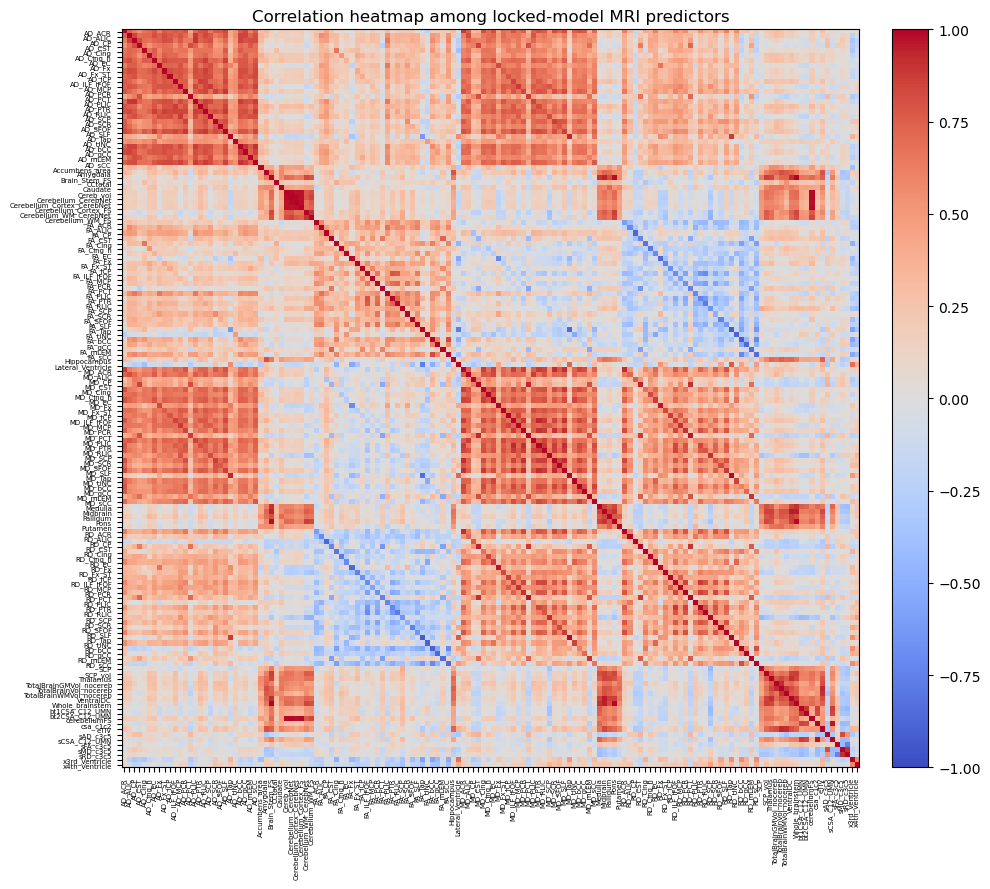

In [10]:
corr_matrix, high_corr_pairs, redundancy_flags = correlation_redundancy(
    locked_fit["standardized_X"],
    threshold=CORRELATION_THRESHOLD,
)
print(f"High-correlation threshold: |r| > {CORRELATION_THRESHOLD}")
print("Correlation matrix")
display(corr_matrix)
print("Highly correlated feature pairs")
display(high_corr_pairs)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr_matrix.to_numpy(dtype=float), vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=5)
ax.set_yticklabels(corr_matrix.index, fontsize=5)
ax.set_title("Correlation heatmap among locked-model MRI predictors")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
display(fig)
plt.close(fig)

## 10. Domain-Level Contributions

Feature domains are derived conservatively from the existing TRACK-FA feature registry and feature names. No unsupported biological domain mapping is added.

Feature-to-domain map


,feature,domain
0,AD_ACR,Brain DTI
1,AD_ALIC,Brain DTI
2,AD_CP,Brain DTI
3,AD_CST,Brain DTI
4,AD_Cing,Brain DTI
...,...,...
141,sFA_c3c5,Spinal cord diffusion
142,sMD_c3c5,Spinal cord diffusion
143,sRD_c3c5,Spinal cord diffusion
144,x3rd_Ventricle,Other MRI


Domain-level annual contributions


,domain,v1_v2_total_contribution,v2_v3_total_contribution,difference,absolute_mean_annual_contribution
0,Other MRI,1.444826,1.156304,0.288522,1.300565
1,Brain DTI,0.368610,0.365453,0.003157,0.367032
2,Brain morphometry,0.254907,0.164731,0.090176,0.209819
3,SCP morphometry,0.106887,0.064419,0.042468,0.085653
4,SCP diffusion,0.043450,0.117589,-0.074139,0.080520
5,Spinal cord diffusion,0.020724,-0.001660,0.022384,0.011192
6,Spinal cord structural,-0.004875,-0.005938,0.001063,0.005406


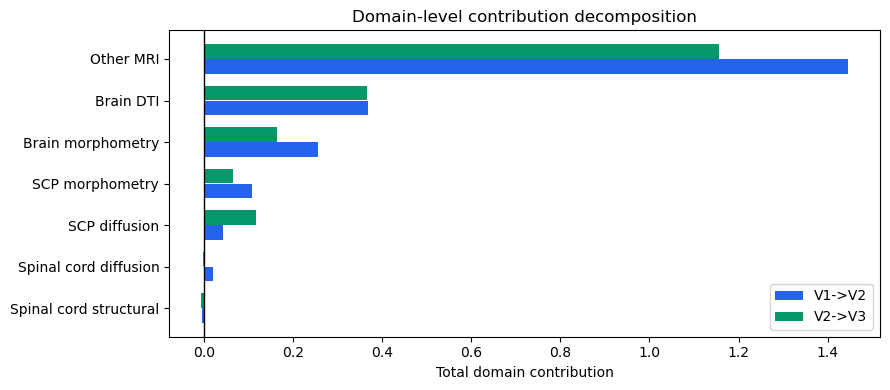

In [11]:
domain_map = infer_feature_domains(selected_features, feature_groups)
domain_table = domain_contributions(contribution_table, domain_map)
print("Feature-to-domain map")
display(domain_map)
print("Domain-level annual contributions")
display(domain_table)

plot_df = domain_table.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
y = np.arange(len(plot_df))
ax.barh(y - 0.18, plot_df["v1_v2_total_contribution"], height=0.35, label="V1->V2", color="#2563eb")
ax.barh(y + 0.18, plot_df["v2_v3_total_contribution"], height=0.35, label="V2->V3", color="#059669")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["domain"])
ax.set_xlabel("Total domain contribution")
ax.set_title("Domain-level contribution decomposition")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 11. Integrated Feature-Importance Table

This table combines the available evidence without creating an arbitrary weighted score. The qualitative label is rule-based and should be read together with the displayed evidence columns.

In [12]:
integrated_table = integrated_feature_importance(
    coef_table,
    bootstrap_table,
    contribution_table,
    lofo_table,
    redundancy_flags,
)
display(integrated_table)
print("Label counts")
display(integrated_table["interpretation_label"].value_counts(dropna=False).rename_axis("label").reset_index(name="n_features"))

,feature,standardised_coefficient,absolute_coefficient,bootstrap_ci_low,bootstrap_ci_high,selection_frequency,sign_consistency,mean_contribution_V1->V2,mean_contribution_V2->V3,d12_loss,d23_loss,annual_performance_loss,strong_correlation_redundancy_flag,interpretation_label
0,Hippocampus,2.743133,2.743133,1.306306,4.559546,1.0,1.000,-0.091431,0.060699,0.043865,0.053300,0.048583,True,Strong robust contributor
1,SCP_vol,-0.658018,0.658018,-1.169013,-0.238114,1.0,0.999,0.106887,0.064419,0.042333,0.020457,0.031395,True,Strong robust contributor
2,x4th_Ventricle,3.282747,3.282747,1.926606,5.407063,1.0,1.000,0.156795,0.179714,-0.001754,0.040389,0.019318,False,Strong robust contributor
3,SCP,-0.529183,0.529183,-0.936214,-0.179497,1.0,1.000,0.094955,0.027489,0.019440,0.018714,0.019077,False,Strong robust contributor
4,Midbrain,-1.564900,1.564900,-2.848139,-0.731152,1.0,1.000,0.090953,0.091747,0.019747,0.008738,0.014242,True,Strong robust contributor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,FA_PCT,-0.047239,0.047239,-0.213751,0.105905,1.0,0.709,-0.005144,0.002435,-0.005063,-0.004227,-0.004645,True,Unstable / uncertain
142,FA_SCP,-0.213049,0.213049,-0.582046,0.050634,1.0,0.945,0.004287,0.024716,-0.009250,-0.000743,-0.004996,False,Unstable / uncertain
143,FA_Cing_h,0.098517,0.098517,-0.054254,0.257482,1.0,0.911,-0.001845,0.005389,-0.011672,0.000675,-0.005498,True,Unstable / uncertain
144,AD_SFOF,-0.097650,0.097650,-0.552277,0.278353,1.0,0.744,0.007925,0.004823,-0.008910,-0.002740,-0.005825,True,Unstable / uncertain


Label counts


,label,n_features
0,Unstable / uncertain,111
1,Strong robust contributor,21
2,Potentially redundant contributor,7
3,Moderate contributor,5
4,Minimal contribution,2


## 12. Final Interpretation

The summary below is generated from the displayed results. It describes model representation and observed longitudinal contribution; it does not make causal claims about disease progression.

In [13]:
def _top_features(frame, col, n=5, abs_sort=True, feature_col="feature"):
    work = frame.copy()
    vals = pd.to_numeric(work[col], errors="coerce")
    order = vals.abs().sort_values(ascending=False).index if abs_sort else vals.sort_values(ascending=False).index
    return work.loc[order, feature_col].head(n).tolist()

largest_weights = _top_features(coef_table, "standardised_coefficient")
most_stable = bootstrap_table.sort_values(["sign_consistency", "selection_frequency"], ascending=[False, False]).head(5)["feature"].tolist()
v12_contrib = _top_features(contribution_table, "mean_contribution_V1->V2")
v23_contrib = _top_features(contribution_table, "mean_contribution_V2->V3")
interval_diff = _top_features(diff_table, "absolute_difference", abs_sort=False)
lofo_loss = lofo_table.sort_values("annual_performance_loss", ascending=False).head(5)["removed_feature"].tolist()
redundant_or_unstable = integrated_table[
    integrated_table["strong_correlation_redundancy_flag"] | integrated_table["interpretation_label"].eq("Unstable / uncertain")
]["feature"].head(10).tolist()
domain_top = domain_table.sort_values("absolute_mean_annual_contribution", ascending=False).head(5)["domain"].tolist()
converging = integrated_table[integrated_table["interpretation_label"].isin(["Strong robust contributor", "Moderate contributor"])]["feature"].head(10).tolist()

summary = pd.DataFrame([
    {"question": "Which features have the largest model weights?", "answer": ", ".join(largest_weights)},
    {"question": "Which features have the most stable weights?", "answer": ", ".join(most_stable)},
    {"question": "Which features contribute most to observed V1->V2 progression?", "answer": ", ".join(v12_contrib)},
    {"question": "Which features contribute most to observed V2->V3 progression?", "answer": ", ".join(v23_contrib)},
    {"question": "Which features explain the largest difference between annual intervals?", "answer": ", ".join(interval_diff)},
    {"question": "Which removals cause the largest reduction in OOF annual d_z?", "answer": ", ".join(lofo_loss)},
    {"question": "Which features appear redundant or unstable?", "answer": ", ".join(redundant_or_unstable) if redundant_or_unstable else "None flagged by the displayed rules"},
    {"question": "Which MRI domains contribute most strongly?", "answer": ", ".join(domain_top)},
    {"question": "Which features have converging evidence?", "answer": ", ".join(converging) if converging else "No features met the displayed converging-evidence rules"},
    {"question": "What can and cannot be claimed?", "answer": "These results identify robust contributors to the model's representation of longitudinal FRDA progression. They do not show that any feature causes disease progression."},
])
# display(summary)

for _, row in summary.iterrows():
    print(f"{row['question']} {row['answer']}")

Which features have the largest model weights? x4th_Ventricle, Hippocampus, TotalBrainWMVol_nocereb, Caudate, Midbrain
Which features have the most stable weights? x4th_Ventricle, Hippocampus, Midbrain, cerebellumFS, Cerebellum_WM_FS
Which features contribute most to observed V1->V2 progression? cerebellumFS, Cerebellum_CerebNet, x4th_Ventricle, Cerebellum_WM_FS, Cerebellum_Cortex_FS
Which features contribute most to observed V2->V3 progression? x4th_Ventricle, Cerebellum_WM_FS, cerebellumFS, Cerebellum_CerebNet, Midbrain
Which features explain the largest difference between annual intervals? Hippocampus, Cerebellum_CerebNet, cerebellumFS, SCP, TotalBrainWMVol_nocereb
Which removals cause the largest reduction in OOF annual d_z? Hippocampus, SCP_vol, x4th_Ventricle, SCP, Midbrain
Which features appear redundant or unstable? Hippocampus, SCP_vol, Midbrain, Cerebellum_WM_FS, Amygdala, TotalBrainWMVol_nocereb, AD_CP, VentralDC, Cerebellum_WM_CerebNet, bt1CSA_C12_UMN
Which MRI domains cont